In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load our champion model and data
model = joblib.load('../models/credit_model.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

X = pd.read_csv('../data/X_features.csv')
y = pd.read_csv('../data/y_target.csv').squeeze()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Model loaded: {type(model).__name__}")
print(f"Test set: {X_test.shape[0]:,} applicants")
print(f"Features: {len(feature_names)}")

Model loaded: XGBClassifier
Test set: 24,190 applicants
Features: 20


In [2]:
# SHAP = SHapley Additive exPlanations
#
# Imagine 5 teammates built a product together
# SHAP asks: "how much did each teammate contribute to the final result?"
# It fairly distributes credit (or blame) across all features
#
# For each prediction, SHAP tells you:
#   - Base rate: "without knowing anything, 6.7% of people default"
#   - Each feature's push: "but this person's high debt ratio PUSHES that up by +12%"
#   - Final prediction: sum of all pushes from the base rate
#
# This is mathematically rigorous — it comes from game theory (Shapley values)

# Create the SHAP explainer
# TreeExplainer is optimised specifically for tree-based models like XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the entire test set
# This tells us WHY the model made each prediction
print("Calculating SHAP values for test set...")
print("(This takes ~1 minute for 24k rows)")

shap_values = explainer.shap_values(X_test)

print(f"\nSHAP values shape: {shap_values.shape}")
print(f"One row per applicant ({X_test.shape[0]:,})")
print(f"One column per feature ({X_test.shape[1]})")
print("\nEach value = how much that feature pushed the prediction up or down")

Calculating SHAP values for test set...
(This takes ~1 minute for 24k rows)

SHAP values shape: (24190, 20)
One row per applicant (24,190)
One column per feature (20)

Each value = how much that feature pushed the prediction up or down


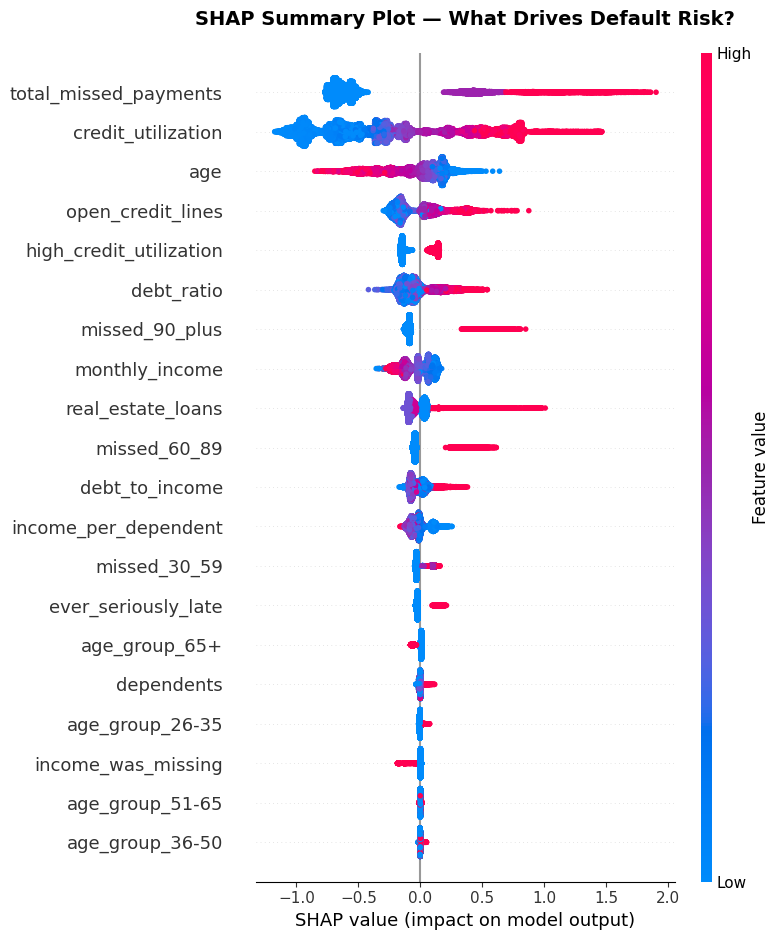

Saved to data/shap_summary.png


In [3]:
# SHAP Summary Plot = the most important chart in your whole project
#
# It answers: "across ALL applicants, which features matter most?"
# 
# How to read it:
#   - Features ranked top to bottom by importance (top = most important)
#   - Each dot = one applicant
#   - Dot color: RED = high feature value, BLUE = low feature value  
#   - Dot position (left/right): negative = pushes toward "fine", positive = pushes toward "default"

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test,
    feature_names=feature_names,
    plot_type="dot",
    show=False,
    max_display=20
)
plt.title("SHAP Summary Plot — What Drives Default Risk?", 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/shap_summary.png")

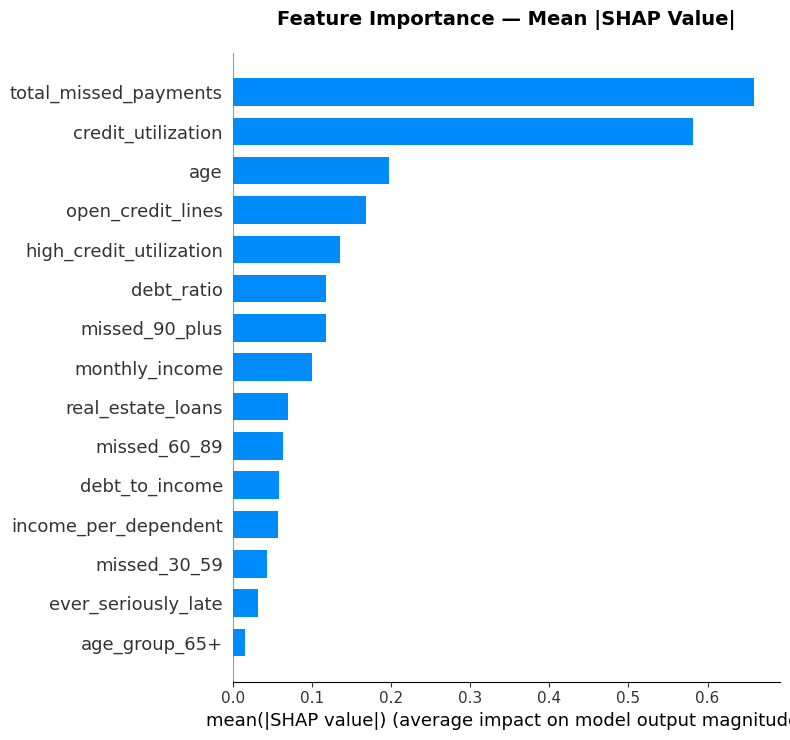

In [4]:
# Mean absolute SHAP value per feature = average impact on predictions
# Simpler than the dot plot, easier to explain to non-technical stakeholders

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    max_display=15
)
plt.title("Feature Importance — Mean |SHAP Value|",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# This is the killer feature of your project
# Pick a specific defaulter from the test set and explain their prediction

# Find a real defaulter in the test set
defaulter_indices = X_test[y_test.values == 1].index
sample_idx = defaulter_indices[0]
sample_position = X_test.index.get_loc(sample_idx)

# Get their data and prediction
applicant = X_test.iloc[sample_position]
predicted_prob = model.predict_proba(X_test.iloc[[sample_position]])[0, 1]
applicant_shap = shap_values[sample_position]

print("=" * 55)
print("  APPLICANT PROFILE")
print("=" * 55)
print(f"  Actual outcome:      {'DEFAULTED ❌' if y_test.iloc[sample_position] == 1 else 'PAID FINE ✅'}")
print(f"  Model's prediction:  {predicted_prob:.1%} default probability")
print(f"  Decision:            {'HIGH RISK 🚨' if predicted_prob > 0.5 else 'LOW RISK ✅'}")
print("=" * 55)
print("\n  Key details about this applicant:")
key_features = ['age', 'monthly_income', 'credit_utilization', 
                'total_missed_payments', 'debt_ratio', 'debt_to_income']
for feat in key_features:
    if feat in applicant.index:
        print(f"  {feat:35s}: {applicant[feat]:.3f}")

  APPLICANT PROFILE
  Actual outcome:      DEFAULTED ❌
  Model's prediction:  10.3% default probability
  Decision:            LOW RISK ✅

  Key details about this applicant:
  age                                : 62.000
  monthly_income                     : 7839.000
  credit_utilization                 : 0.060
  total_missed_payments              : 0.000
  debt_ratio                         : 0.109
  debt_to_income                     : 857.891


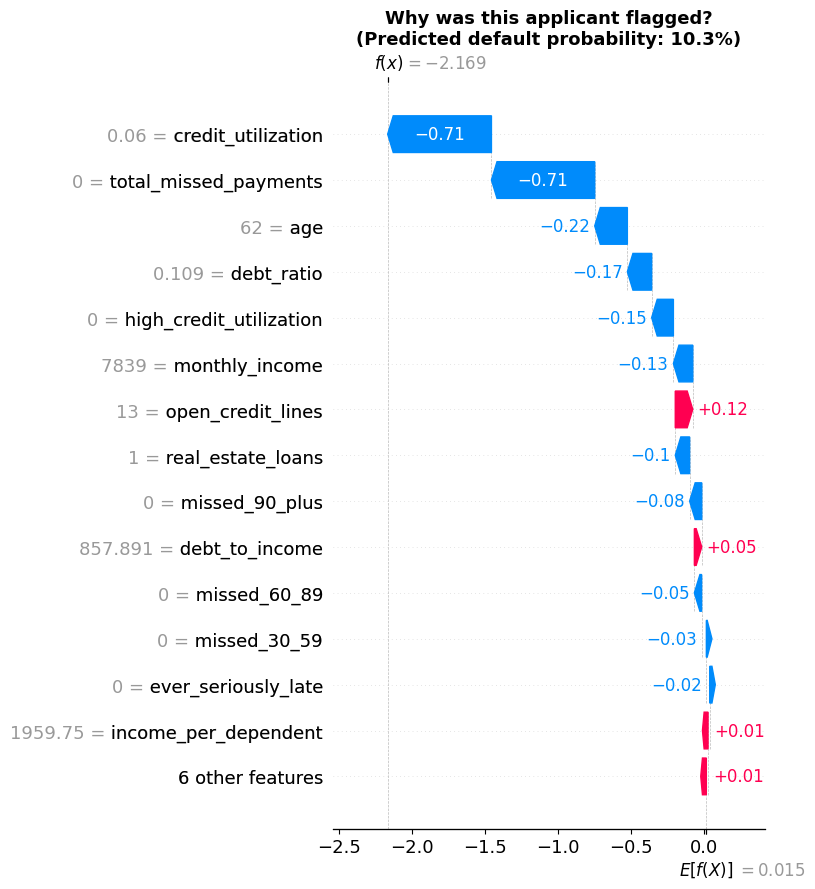

Saved! This chart is your project's hero image.


In [6]:
# Waterfall plot = the most intuitive explanation chart
#
# It starts at the BASE RATE (average prediction for everyone)
# Then shows each feature either PUSHING UP (red) or PUSHING DOWN (blue)
# Until it reaches THIS applicant's final prediction
#
# This is what you'd show a loan officer to explain a rejection

shap_explanation = shap.Explanation(
    values=applicant_shap,
    base_values=explainer.expected_value,
    data=applicant.values,
    feature_names=feature_names
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_explanation, max_display=15, show=False)
plt.title(f"Why was this applicant flagged?\n(Predicted default probability: {predicted_prob:.1%})",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved! This chart is your project's hero image.")

In [7]:
# This is the feature that makes your project regulation-ready
# ECOA (Equal Credit Opportunity Act) requires lenders to give
# specific reasons for credit denial — this generates those reasons automatically

def generate_plain_english_reasons(applicant_data, shap_vals, feature_names, 
                                    predicted_prob, top_n=3):
    """
    Takes SHAP values for one applicant.
    Returns human-readable sentences explaining the decision.
    This is what a loan officer actually reads.
    """
    
    # Pair each feature with its SHAP value
    feature_impacts = list(zip(feature_names, shap_vals, applicant_data))
    
    # Sort by absolute SHAP value — biggest impact features first
    feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)
    top_features = feature_impacts[:top_n]
    
    # Plain English templates for each feature
    # Maps feature name → human readable explanation
    reason_templates = {
        'credit_utilization': {
            'high': f"Credit utilization is {{val:.0%}}, indicating most available credit is being used (high-risk threshold: 30%)",
            'low':  f"Credit utilization is {{val:.0%}}, well within healthy range"
        },
        'total_missed_payments': {
            'high': f"{{val:.0f}} missed payment(s) recorded across all accounts",
            'low':  f"No missed payments recorded — strong payment history"
        },
        'monthly_income': {
            'high': f"Monthly income of ${{val:,.0f}} supports this loan size",
            'low':  f"Monthly income of ${{val:,.0f}} is below the typical approved applicant"
        },
        'debt_to_income': {
            'high': f"Debt-to-income ratio of {{val:.2f}} is elevated — significant existing debt obligations",
            'low':  f"Debt-to-income ratio of {{val:.2f}} is within acceptable range"
        },
        'debt_ratio': {
            'high': f"Debt ratio of {{val:.2f}} suggests high existing financial obligations",
            'low':  f"Debt ratio of {{val:.2f}} is manageable"
        },
        'age': {
            'high': f"Applicant age of {{val:.0f}} is within the lower-risk range",
            'low':  f"Applicant age of {{val:.0f}} — younger applicants show statistically higher default rates"
        },
        'ever_seriously_late': {
            'high': f"Previous serious delinquency (90+ days late) on record — significant risk factor",
            'low':  f"No serious delinquency history"
        },
        'missed_90_plus': {
            'high': f"{{val:.0f}} instance(s) of being 90+ days past due — serious delinquency history",
            'low':  f"No 90+ day delinquencies recorded"
        },
        'open_credit_lines': {
            'high': f"{{val:.0f}} open credit lines — higher exposure",
            'low':  f"{{val:.0f}} open credit lines — manageable credit exposure"
        },
        'income_per_dependent': {
            'high': f"Available income per dependent of ${{val:,.0f}} — adequate financial buffer",
            'low':  f"Available income per dependent of ${{val:,.0f}} — financial pressure from dependents"
        }
    }
    
    # Decision header
    if predicted_prob >= 0.7:
        decision = "HIGH RISK — Application Flagged for Review"
        emoji = "🚨"
    elif predicted_prob >= 0.4:
        decision = "MODERATE RISK — Manual Review Recommended"
        emoji = "⚠️"
    else:
        decision = "LOW RISK — Application Approved"
        emoji = "✅"
    
    print("=" * 60)
    print(f"  CREDIT DECISION EXPLANATION")
    print("=" * 60)
    print(f"  {emoji}  {decision}")
    print(f"  Default Probability: {predicted_prob:.1%}")
    print("=" * 60)
    print(f"\n  TOP {top_n} REASONS FOR THIS DECISION:")
    print()
    
    reasons = []
    for i, (feature, shap_val, value) in enumerate(top_features, 1):
        direction = 'high' if shap_val > 0 else 'low'
        impact = 'increases' if shap_val > 0 else 'decreases'
        arrow = '⬆️ RISK+' if shap_val > 0 else '⬇️ RISK-'
        
        # Get template or generate generic reason
        if feature in reason_templates:
            template = reason_templates[feature][direction]
            reason_text = template.format(val=value)
        else:
            reason_text = f"{feature.replace('_', ' ').title()}: {value:.3f} — {impact} default risk"
        
        print(f"  {i}. [{arrow}] {reason_text}")
        print(f"      (SHAP impact: {shap_val:+.4f})")
        print()
        reasons.append(reason_text)
    
    print("=" * 60)
    print("  ℹ️  This explanation is generated in compliance with")
    print("     adverse action notice requirements (ECOA/FCRA)")
    print("=" * 60)
    
    return reasons

# Run it on our sample applicant
reasons = generate_plain_english_reasons(
    applicant_data=applicant.values,
    shap_vals=applicant_shap,
    feature_names=feature_names,
    predicted_prob=predicted_prob
)

  CREDIT DECISION EXPLANATION
  ✅  LOW RISK — Application Approved
  Default Probability: 10.3%

  TOP 3 REASONS FOR THIS DECISION:

  1. [⬇️ RISK-] Credit utilization is 6%, well within healthy range
      (SHAP impact: -0.7113)

  2. [⬇️ RISK-] No missed payments recorded — strong payment history
      (SHAP impact: -0.7078)

  3. [⬇️ RISK-] Applicant age of 62 — younger applicants show statistically higher default rates
      (SHAP impact: -0.2238)

  ℹ️  This explanation is generated in compliance with
     adverse action notice requirements (ECOA/FCRA)


In [8]:
# Let's see it work on 3 different people:
# a clear defaulter, a borderline case, and a clear approval

y_test_reset = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)
probs = model.predict_proba(X_test_reset)[:, 1]

# Find good examples
high_risk_idx   = probs.argmax()
low_risk_idx    = probs.argmin()
borderline_idx  = (abs(probs - 0.5)).argmin()

print("Testing on 3 different applicant types...\n")

for label, idx in [("HIGH RISK APPLICANT", high_risk_idx), 
                    ("BORDERLINE APPLICANT", borderline_idx),
                    ("LOW RISK APPLICANT", low_risk_idx)]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    generate_plain_english_reasons(
        applicant_data=X_test_reset.iloc[idx].values,
        shap_vals=shap_values[idx],
        feature_names=feature_names,
        predicted_prob=probs[idx],
        top_n=3
    )

Testing on 3 different applicant types...


  HIGH RISK APPLICANT
  CREDIT DECISION EXPLANATION
  🚨  HIGH RISK — Application Flagged for Review
  Default Probability: 98.3%

  TOP 3 REASONS FOR THIS DECISION:

  1. [⬆️ RISK+] 9 missed payment(s) recorded across all accounts
      (SHAP impact: +1.3634)

  2. [⬆️ RISK+] Credit utilization is 107%, indicating most available credit is being used (high-risk threshold: 30%)
      (SHAP impact: +0.9463)

  3. [⬆️ RISK+] 3 instance(s) of being 90+ days past due — serious delinquency history
      (SHAP impact: +0.5245)

  ℹ️  This explanation is generated in compliance with
     adverse action notice requirements (ECOA/FCRA)

  BORDERLINE APPLICANT
  CREDIT DECISION EXPLANATION
  ⚠️  MODERATE RISK — Manual Review Recommended
  Default Probability: 50.0%

  TOP 3 REASONS FOR THIS DECISION:

  1. [⬇️ RISK-] Credit utilization is 15%, well within healthy range
      (SHAP impact: -0.4505)

  2. [⬆️ RISK+] 1 missed payment(s) recorded across all 

In [9]:
# We'll need the explainer in Phase 6 (FastAPI)
# Save it now so we don't recalculate SHAP values on every API request

joblib.dump(explainer, '../models/shap_explainer.pkl')
print("✅ SHAP explainer saved to ../models/shap_explainer.pkl")

# Quick sanity check — reload and verify it works
explainer_reloaded = joblib.load('../models/shap_explainer.pkl')
test_shap = explainer_reloaded.shap_values(X_test.iloc[:5])
print(f"✅ Reloaded explainer works — shape: {test_shap.shape}")

print("\n📦 Everything saved:")
print("   models/credit_model.pkl       — champion XGBoost model")
print("   models/shap_explainer.pkl     — SHAP explainer")
print("   models/feature_names.pkl      — feature list")
print("\n🎯 Ready for Phase 6 — FastAPI!")

✅ SHAP explainer saved to ../models/shap_explainer.pkl
✅ Reloaded explainer works — shape: (5, 20)

📦 Everything saved:
   models/credit_model.pkl       — champion XGBoost model
   models/shap_explainer.pkl     — SHAP explainer
   models/feature_names.pkl      — feature list

🎯 Ready for Phase 6 — FastAPI!
